In [3]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('wnba_shots_2025.csv')
data = df['SHOT_DISTANCE'].dropna().values

In [5]:
# Scale data to (0, 1) range for Beta distribution fitting
min_val, max_val = data.min(), data.max()
eps = 1e-5
data_scaled = (data - min_val + eps) / (max_val - min_val + 2 * eps)

In [6]:
# Gamma
params_gamma = stats.gamma.fit(data)
ll_gamma = np.sum(stats.gamma.logpdf(data, *params_gamma))

In [7]:
# Beta
params_beta = stats.beta.fit(data_scaled)
ll_beta_raw = np.sum(stats.beta.logpdf(data_scaled, *params_beta))
ll_beta = ll_beta_raw - len(data) * np.log(max_val - min_val + 2 * eps) # Change of variables adjustment

In [8]:
# Normal
params_norm = stats.norm.fit(data)
ll_norm = np.sum(stats.norm.logpdf(data, *params_norm))

In [9]:
# Exponential
params_expon = stats.expon.fit(data)
ll_expon = np.sum(stats.expon.logpdf(data, *params_expon))

In [10]:
# Poisson (Discrete fit on integer-rounded feet)
data_int = np.round(data).astype(int)
mu_poisson = np.mean(data_int)
ll_poisson = np.sum(stats.poisson.logpmf(data_int, mu_poisson))

In [11]:
# Print Log-Likelihood Summary Table
print("=== LOG-LIKELIHOOD COMPARISON ===")
print(f"Gamma Distribution:       {ll_gamma:.2f}")
print(f"Beta Distribution:        {ll_beta:.2f}")
print(f"Normal Distribution:      {ll_norm:.2f}")
print(f"Exponential Distribution: {ll_expon:.2f}")
print(f"Poisson Distribution:     {ll_poisson:.2f}")

=== LOG-LIKELIHOOD COMPARISON ===
Gamma Distribution:       -132762.01
Beta Distribution:        -117060.57
Normal Distribution:      -143138.23
Exponential Distribution: -137325.98
Poisson Distribution:     -241952.94


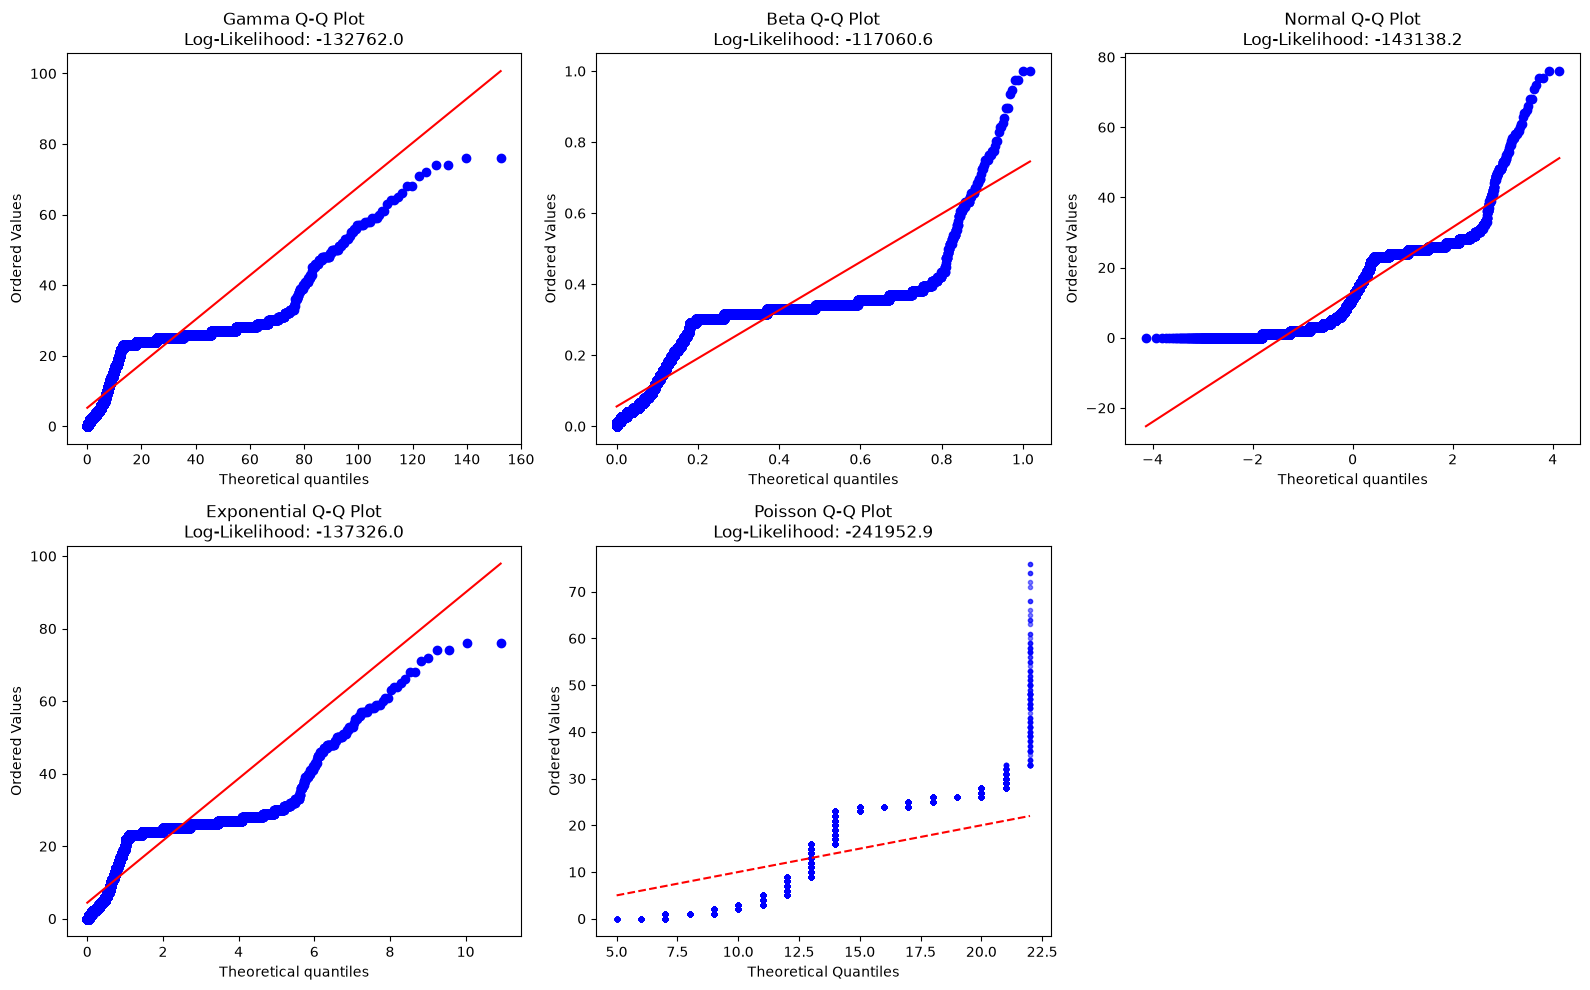

In [16]:
# 3. Q-Q Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Gamma Q-Q
stats.probplot(data, dist="gamma", sparams=params_gamma, plot=axes[0])
axes[0].set_title(f"Gamma Q-Q Plot\nLog-Likelihood: {ll_gamma:.1f}")

# Beta Q-Q
stats.probplot(data_scaled, dist="beta", sparams=params_beta, plot=axes[1])
axes[1].set_title(f"Beta Q-Q Plot\nLog-Likelihood: {ll_beta:.1f}")

# Normal Q-Q
stats.probplot(data, dist="norm", plot=axes[2])
axes[2].set_title(f"Normal Q-Q Plot\nLog-Likelihood: {ll_norm:.1f}")

# Exponential Q-Q
stats.probplot(data, dist="expon", plot=axes[3])
axes[3].set_title(f"Exponential Q-Q Plot\nLog-Likelihood: {ll_expon:.1f}")

# Poisson Q-Q
quantiles = np.linspace(0.01, 0.99, len(data))
theo_poisson = stats.poisson.ppf(quantiles, mu_poisson)
axes[4].plot(theo_poisson, np.sort(data_int), 'b.', alpha=0.5)
axes[4].plot([min(theo_poisson), max(theo_poisson)], [min(theo_poisson), max(theo_poisson)], 'r--')
axes[4].set_title(f"Poisson Q-Q Plot\nLog-Likelihood: {ll_poisson:.1f}")
axes[4].set_xlabel("Theoretical Quantiles")
axes[4].set_ylabel("Ordered Values")

fig.delaxes(axes[5]) # Remove empty 6th subplot
plt.tight_layout()
plt.show()